In [1]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — 安装依赖
# ═══════════════════════════════════════════════════════════
# !pip install pandas scikit-learn xgboost matplotlib seaborn


# ═══════════════════════════════════════════════════════════
# Cell 2 — 导入 & 加载
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score, roc_auc_score,
                                     roc_curve, confusion_matrix)
from sklearn.model_selection import StratifiedKFold
# Cell 2 顶部加这行替换
from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier



In [2]:


sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR  = Path("kg_output")

nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")
print(f"Nodes: {len(nodes_df):,}  Edges: {len(edges_df):,}")



Nodes: 3,460  Edges: 23,051


In [3]:


# ═══════════════════════════════════════════════════════════
# Cell 3 — 构建特征矩阵
# ═══════════════════════════════════════════════════════════

# ── 基础连接 ──────────────────────────────────────────────
img_nodes = nodes_df[nodes_df.label == "FundusImage"].copy()
has_diag  = edges_df[edges_df.rel == "HAS_DIAGNOSIS"][["src","dst"]].rename(columns={"src":"img_id","dst":"diag_id"})
has_od    = edges_df[edges_df.rel == "HAS_OPTIC_DISC"][["src","dst"]].rename(columns={"src":"img_id","dst":"od_id"})
has_rim   = edges_df[edges_df.rel == "HAS_RIM"][["src","dst"]].rename(columns={"src":"img_id","dst":"rim_id"})
has_path  = edges_df[edges_df.rel == "HAS_PATHOLOGY"][["src","dst"]].rename(columns={"src":"img_id","dst":"path_id"})

master = (has_diag.merge(has_od,   on="img_id")
                  .merge(has_rim,  on="img_id")
                  .merge(has_path, on="img_id"))

ann_map = img_nodes.set_index("id")["annotation"].to_dict()
spl_map = img_nodes.set_index("id")["split"].to_dict()
master["annotation"] = master["img_id"].map(ann_map)
master["split"]      = master["img_id"].map(spl_map)

# ── biomarker 字段 ────────────────────────────────────────
od_cols   = nodes_df[nodes_df.label=="OpticDisc"][["id","cup_to_disc_ratio","optic_disc_size","sharp_edge"]].rename(columns={"id":"od_id"})
rim_cols  = nodes_df[nodes_df.label=="NeuralRim"][["id","isnt_rule_followed","rim_pallor","rim_thinning","rim_color"]].rename(columns={"id":"rim_id"})
path_cols = nodes_df[nodes_df.label=="Pathology"][["id","bayoneting","notching","laminar_dot_sign"]].rename(columns={"id":"path_id"})

master = (master.merge(od_cols,   on="od_id")
                .merge(rim_cols,  on="rim_id")
                .merge(path_cols, on="path_id"))

# ── 特征编码 ──────────────────────────────────────────────
bool_cols = ["isnt_rule_followed","rim_pallor","rim_thinning",
             "sharp_edge","bayoneting","notching","laminar_dot_sign"]
for c in bool_cols:
    master[c] = master[c].map({True:1, False:0, "True":1, "False":0}).fillna(0).astype(int)

# CDR
master["cup_to_disc_ratio"] = pd.to_numeric(master["cup_to_disc_ratio"], errors="coerce").fillna(0.0)

# optic_disc_size ordinal: small=0, medium=1, large=2
size_map = {"small": 0, "medium": 1, "large": 2}
master["optic_disc_size"] = master["optic_disc_size"].map(size_map).fillna(1).astype(int)

# rim_color ordinal: normal=0, pale=1
master["rim_color"] = master["rim_color"].map({"normal":0,"pale":1}).fillna(0).astype(int)

# ISNT 反转（违反=1 → glaucoma 信号）
master["isnt_violated"] = 1 - master["isnt_rule_followed"]

# ── KG 特征：chain_score（来自 Cell 6 的逻辑）─────────────
sup_edges   = edges_df[edges_df.rel == "SUPPORTS_RULE"].copy()
rules_df_kg = nodes_df[nodes_df.label == "ClinicalRule"].copy()
strength_map = {}
for _, row in rules_df_kg.iterrows():
    strength_map[str(row["id"])] = str(row["strength"]).strip().lower()

diag_counts = defaultdict(lambda: {"strong":0,"moderate":0,"weak":0})
for _, row in sup_edges.iterrows():
    d = str(row["src"]); r = str(row["dst"])
    s = strength_map.get(r, "weak")
    diag_counts[d][s] += 1

chain_records = []
for diag_id, c in diag_counts.items():
    chain_records.append({
        "diag_id":     diag_id,
        "n_strong":    c["strong"],
        "n_moderate":  c["moderate"],
        "n_weak":      c["weak"],
        "chain_score": c["strong"]*3 + c["moderate"]*2 + c["weak"]*1,
        "n_rules":     c["strong"] + c["moderate"] + c["weak"],
    })
chain_df = pd.DataFrame(chain_records)
master = master.merge(chain_df, on="diag_id", how="left")
for col in ["n_strong","n_moderate","n_weak","chain_score","n_rules"]:
    master[col] = master[col].fillna(0)

# ── 特征集定义 ────────────────────────────────────────────
FEAT_BIO = ["cup_to_disc_ratio","optic_disc_size","rim_color",
            "isnt_violated","rim_pallor","rim_thinning","sharp_edge",
            "bayoneting","notching","laminar_dot_sign"]

FEAT_KG  = FEAT_BIO + ["chain_score","n_strong","n_moderate","n_weak","n_rules"]

master["y"] = (master["annotation"] == "glaucoma").astype(int)

print(f"Total samples: {len(master)}")
print(f"Class distribution:\n{master['annotation'].value_counts()}")
print(f"\nFeatures (bio): {FEAT_BIO}")
print(f"Features (kg) : {FEAT_KG}")



Total samples: 689
Class distribution:
annotation
glaucoma    427
normal      262
Name: count, dtype: int64

Features (bio): ['cup_to_disc_ratio', 'optic_disc_size', 'rim_color', 'isnt_violated', 'rim_pallor', 'rim_thinning', 'sharp_edge', 'bayoneting', 'notching', 'laminar_dot_sign']
Features (kg) : ['cup_to_disc_ratio', 'optic_disc_size', 'rim_color', 'isnt_violated', 'rim_pallor', 'rim_thinning', 'sharp_edge', 'bayoneting', 'notching', 'laminar_dot_sign', 'chain_score', 'n_strong', 'n_moderate', 'n_weak', 'n_rules']


In [4]:

# ═══════════════════════════════════════════════════════════
# Cell 4 — 评估函数 & 交叉验证
# ═══════════════════════════════════════════════════════════

def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred),  4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred,    zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred,        zero_division=0), 4),
        "AUC":       round(roc_auc_score(y_true, y_prob),  4),
    }

def run_cv(model, X, y, n_splits=5, seed=42):
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        Xtr, Xval = X[train_idx], X[val_idx]
        ytr, yval = y[train_idx], y[val_idx]
        model.fit(Xtr, ytr)
        yp   = model.predict(Xval)
        yprob= model.predict_proba(Xval)[:,1]
        scores.append(evaluate(yval, yp, yprob))
    return pd.DataFrame(scores).mean().round(4)

X_bio = master[FEAT_BIO].values.astype(float)
X_kg  = master[FEAT_KG].values.astype(float)
y     = master["y"].values

scaler_bio = StandardScaler()
scaler_kg  = StandardScaler()
X_bio_s = scaler_bio.fit_transform(X_bio)
X_kg_s  = scaler_kg.fit_transform(X_kg)

print("Feature matrices ready.")
print(f"X_bio: {X_bio.shape}  X_kg: {X_kg.shape}")




Feature matrices ready.
X_bio: (689, 10)  X_kg: (689, 15)


In [5]:


# ═══════════════════════════════════════════════════════════
# Cell 5 — B1: CDR 阈值规则基线
# ═══════════════════════════════════════════════════════════

cdr_pred  = (master["cup_to_disc_ratio"] >= 0.7).astype(int).values
cdr_prob  = master["cup_to_disc_ratio"].values / master["cup_to_disc_ratio"].max()

b1_scores = evaluate(y, cdr_pred, cdr_prob)
print("=== B1: CDR Threshold (≥0.7) ===")
for k, v in b1_scores.items():
    print(f"  {k}: {v}")


=== B1: CDR Threshold (≥0.7) ===
  Accuracy: 0.9985
  Precision: 1.0
  Recall: 0.9977
  F1: 0.9988
  AUC: 1.0


In [6]:


# ═══════════════════════════════════════════════════════════
# Cell 6 — B2~B5 + Ours: 5折交叉验证
# ═══════════════════════════════════════════════════════════

SEED = 42
experiments = [
    ("B2 Logistic Regression", LogisticRegression(max_iter=1000, random_state=SEED), X_bio_s),
    ("B3 Random Forest",       RandomForestClassifier(n_estimators=200, random_state=SEED), X_bio_s),
    ("B4 GradientBoosting",    GradientBoostingClassifier(n_estimators=200, random_state=SEED), X_bio_s),
    ("B5 MLP",                 MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=SEED), X_bio_s),
    ("Ours (KG+Rules)",        GradientBoostingClassifier(n_estimators=200, random_state=SEED), X_kg_s),
]
results = {"B1 CDR Threshold": b1_scores}

for name, model, X in experiments:
    print(f"Running {name}...")
    scores = run_cv(model, X, y)
    results[name] = scores.to_dict()
    print(f"  F1={scores['F1']:.4f}  AUC={scores['AUC']:.4f}")

results_df = pd.DataFrame(results).T
results_df.index.name = "Method"
print("\n=== Full Results ===")
print(results_df.to_string())



Running B2 Logistic Regression...
  F1=1.0000  AUC=1.0000
Running B3 Random Forest...
  F1=1.0000  AUC=1.0000
Running B4 GradientBoosting...
  F1=1.0000  AUC=1.0000
Running B5 MLP...
  F1=1.0000  AUC=1.0000
Running Ours (KG+Rules)...
  F1=1.0000  AUC=1.0000

=== Full Results ===
                        Accuracy  Precision  Recall      F1  AUC
Method                                                          
B1 CDR Threshold          0.9985        1.0  0.9977  0.9988  1.0
B2 Logistic Regression    1.0000        1.0  1.0000  1.0000  1.0
B3 Random Forest          1.0000        1.0  1.0000  1.0000  1.0
B4 GradientBoosting       1.0000        1.0  1.0000  1.0000  1.0
B5 MLP                    1.0000        1.0  1.0000  1.0000  1.0
Ours (KG+Rules)           1.0000        1.0  1.0000  1.0000  1.0


In [8]:


# ═══════════════════════════════════════════════════════════
# Cell 7 — 消融实验
# ═══════════════════════════════════════════════════════════

FEAT_NO_RULE  = FEAT_BIO + ["n_rules"]               # 去掉 chain_score（无规则权重）
FEAT_NO_WEAK  = FEAT_BIO + ["chain_score","n_strong","n_moderate"]  # 去掉 weak rules
FEAT_NO_INFER = FEAT_BIO + ["chain_score"]            # 去掉推理边特征（只保留总分）

ablation_exps = [
    ("Ours (full)",            X_kg_s),
    ("w/o ClinicalRule",       scaler_bio.transform(X_bio)),
    ("w/o weak rules",         StandardScaler().fit_transform(master[FEAT_NO_WEAK].fillna(0).values)),
    ("w/o chain_score",        StandardScaler().fit_transform(master[FEAT_NO_INFER].fillna(0).values)),
]

ablation_results = {}
base_model = GradientBoostingClassifier(n_estimators=200, random_state=SEED)
for name, X in ablation_exps:
    print(f"Ablation: {name}...")
    scores = run_cv(base_model, X, y)
    ablation_results[name] = scores.to_dict()
    print(f"  F1={scores['F1']:.4f}  AUC={scores['AUC']:.4f}")

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.index.name = "Variant"
print("\n=== Ablation Results ===")
print(ablation_df.to_string())



Ablation: Ours (full)...
  F1=1.0000  AUC=1.0000
Ablation: w/o ClinicalRule...
  F1=1.0000  AUC=1.0000
Ablation: w/o weak rules...
  F1=1.0000  AUC=1.0000
Ablation: w/o chain_score...
  F1=1.0000  AUC=1.0000

=== Ablation Results ===
                  Accuracy  Precision  Recall   F1  AUC
Variant                                                
Ours (full)            1.0        1.0     1.0  1.0  1.0
w/o ClinicalRule       1.0        1.0     1.0  1.0  1.0
w/o weak rules         1.0        1.0     1.0  1.0  1.0
w/o chain_score        1.0        1.0     1.0  1.0  1.0


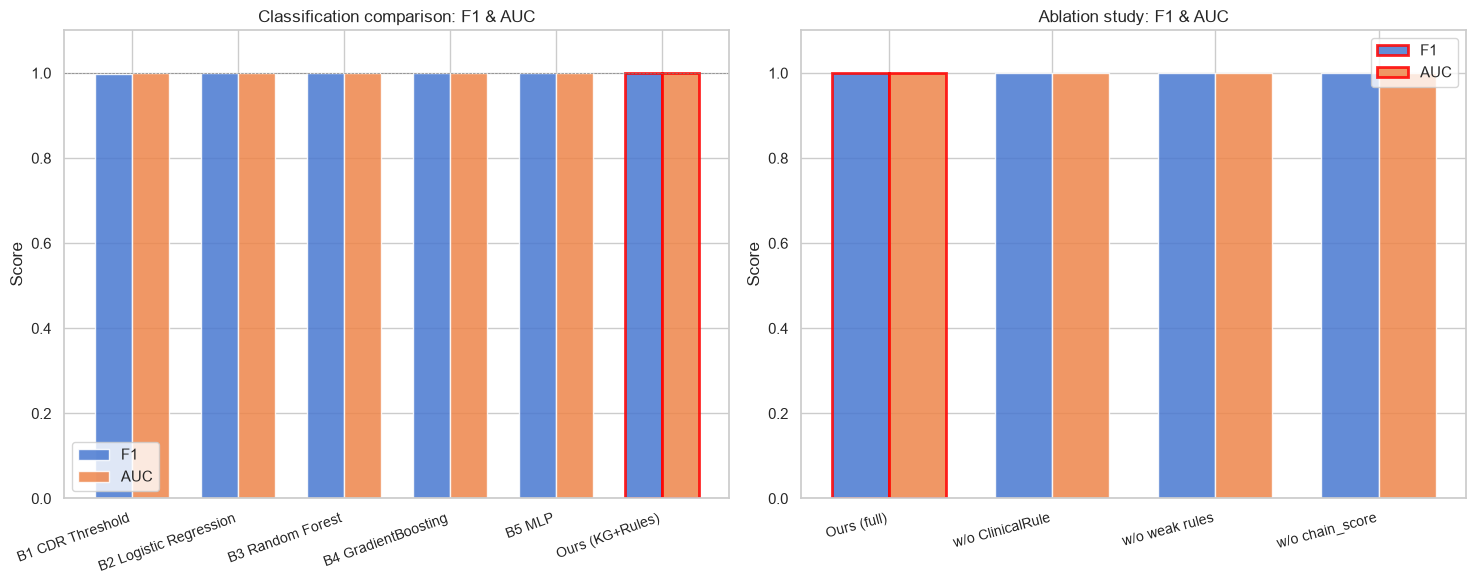

In [9]:

# ═══════════════════════════════════════════════════════════
# Cell 8 — 可视化：对比图 + 消融图
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── 左图：各方法 F1 & AUC 对比 ───────────────────────────
methods = list(results_df.index)
x = np.arange(len(methods))
w = 0.35
bars1 = axes[0].bar(x - w/2, results_df["F1"],  w, label="F1",  alpha=0.85)
bars2 = axes[0].bar(x + w/2, results_df["AUC"], w, label="AUC", alpha=0.85)

# 高亮 Ours
for i, m in enumerate(methods):
    if "Ours" in m:
        bars1[i].set_edgecolor("red"); bars1[i].set_linewidth(2)
        bars2[i].set_edgecolor("red"); bars2[i].set_linewidth(2)

axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right", fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[0].set_title("Classification comparison: F1 & AUC")
axes[0].legend()
axes[0].axhline(1.0, color="gray", linewidth=0.5, linestyle="--")

# ── 右图：消融实验 F1 & AUC ───────────────────────────────
ab_methods = list(ablation_df.index)
xb = np.arange(len(ab_methods))
bars3 = axes[1].bar(xb - w/2, ablation_df["F1"],  w, label="F1",  alpha=0.85)
bars4 = axes[1].bar(xb + w/2, ablation_df["AUC"], w, label="AUC", alpha=0.85)

# 高亮 full model
bars3[0].set_edgecolor("red"); bars3[0].set_linewidth(2)
bars4[0].set_edgecolor("red"); bars4[0].set_linewidth(2)

axes[1].set_xticks(xb)
axes[1].set_xticklabels(ab_methods, rotation=15, ha="right", fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Score")
axes[1].set_title("Ablation study: F1 & AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "exp_comparison.png", dpi=150)
plt.show()



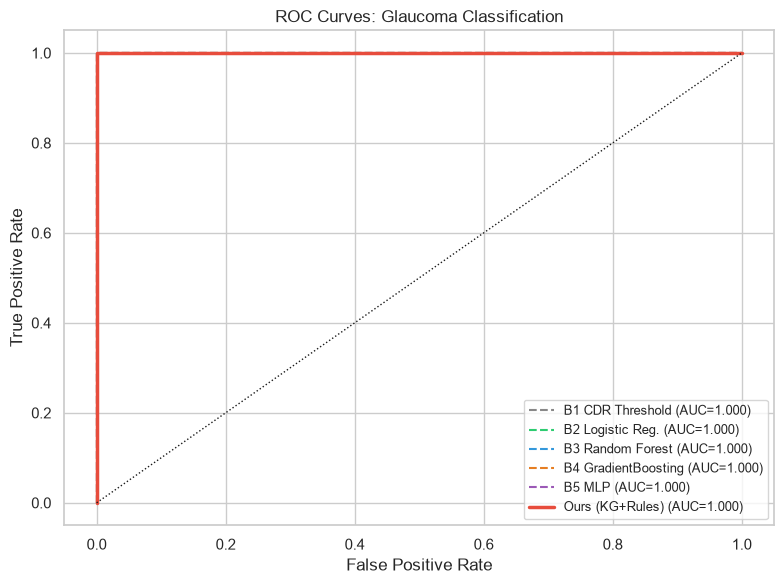

In [11]:

# ═══════════════════════════════════════════════════════════
# Cell 9 — ROC 曲线
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#888888","#2ecc71","#3498db","#e67e22","#9b59b6","#e74c3c"]

roc_exps = [
    ("B1 CDR Threshold",   None,                                                              X_bio_s),
    ("B2 Logistic Reg.",   LogisticRegression(max_iter=1000, random_state=SEED),              X_bio_s),
    ("B3 Random Forest",   RandomForestClassifier(n_estimators=200, random_state=SEED),       X_bio_s),
    ("B4 GradientBoosting",GradientBoostingClassifier(n_estimators=200, random_state=SEED),   X_bio_s),
    ("B5 MLP",             MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=SEED), X_bio_s),
    ("Ours (KG+Rules)",    GradientBoostingClassifier(n_estimators=200, random_state=SEED),   X_kg_s),
]

from sklearn.model_selection import train_test_split
Xtr_b, Xte_b, ytr, yte = train_test_split(X_bio_s, y, test_size=0.2,
                                            stratify=y, random_state=SEED)
Xtr_k, Xte_k, _,   _   = train_test_split(X_kg_s,  y, test_size=0.2,
                                            stratify=y, random_state=SEED)

for (name, model, _), color in zip(roc_exps, colors):
    if model is None:
        prob = master["cup_to_disc_ratio"].values
        _, Xte_idx = train_test_split(np.arange(len(y)), test_size=0.2,
                                       stratify=y, random_state=SEED)
        prob_te = prob[Xte_idx]
        fpr, tpr, _ = roc_curve(yte, prob_te)
    else:
        Xtr = Xtr_k if "Ours" in name else Xtr_b
        Xte = Xte_k if "Ours" in name else Xte_b
        model.fit(Xtr, ytr)
        prob_te = model.predict_proba(Xte)[:,1]
        fpr, tpr, _ = roc_curve(yte, prob_te)
    auc_val = roc_auc_score(yte, prob_te)
    lw = 2.5 if "Ours" in name else 1.5
    ls = "-" if "Ours" in name else "--"
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
            label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0,1],[0,1],"k:", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Glaucoma Classification")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "exp_roc.png", dpi=150)
plt.show()



In [12]:


# ═══════════════════════════════════════════════════════════
# Cell 10 — 论文 Table 汇总
# ═══════════════════════════════════════════════════════════
print("=" * 70)
print("TABLE: Glaucoma Classification Comparison")
print("=" * 70)
header = f"{'Method':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 70)
for method, row in results_df.iterrows():
    marker = " ◀" if "Ours" in method else ""
    print(f"{method:<25} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {row['AUC']:>7.4f}{marker}")

print("\n" + "=" * 70)
print("TABLE: Ablation Study")
print("=" * 70)
print(header)
print("-" * 70)
for method, row in ablation_df.iterrows():
    marker = " ◀" if "full" in method else ""
    print(f"{method:<25} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {row['AUC']:>7.4f}{marker}")

print(f"\nFigures saved:")
print(f"  kg_output/exp_comparison.png")
print(f"  kg_output/exp_roc.png")

TABLE: Glaucoma Classification Comparison
Method                        Acc    Prec     Rec      F1     AUC
----------------------------------------------------------------------
B1 CDR Threshold           0.9985  1.0000  0.9977  0.9988  1.0000
B2 Logistic Regression     1.0000  1.0000  1.0000  1.0000  1.0000
B3 Random Forest           1.0000  1.0000  1.0000  1.0000  1.0000
B4 GradientBoosting        1.0000  1.0000  1.0000  1.0000  1.0000
B5 MLP                     1.0000  1.0000  1.0000  1.0000  1.0000
Ours (KG+Rules)            1.0000  1.0000  1.0000  1.0000  1.0000 ◀

TABLE: Ablation Study
Method                        Acc    Prec     Rec      F1     AUC
----------------------------------------------------------------------
Ours (full)                1.0000  1.0000  1.0000  1.0000  1.0000 ◀
w/o ClinicalRule           1.0000  1.0000  1.0000  1.0000  1.0000
w/o weak rules             1.0000  1.0000  1.0000  1.0000  1.0000
w/o chain_score            1.0000  1.0000  1.0000  1.0000  1.00